In [1]:
# Import libraries
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Enable inline plotting
%matplotlib inline

# Set consistent plot style (matching namespace_resources.ipynb)
sns.set_theme(style='whitegrid', font_scale=1.7)

print("Libraries loaded ✓")

Libraries loaded ✓


## Configuration

Configure the Kubernetes namespaces and pod selectors for each RIC component.

In [2]:
# Kubernetes Configuration
KUBECONFIG = None  # Set path if not using default ~/.kube/config

# Namespace configuration for O-RAN components (including SMO and Non-RT RIC)
NAMESPACES = {
    "frontend": "Frontend (User Interface - Intent Submission)",
    "smo": "SMO (MCP Client/Server - Intent Management)",
    "ricrapp": "rApp (rApps - Intent to Policy Translation)",
    "nonrtric": "Non-RT RIC (Policy Management, Gateway)",
    "ricplt": "Near-RT RIC Platform (A1 Mediator, E2Term, E2Mgr)",
    "ricxapp": "Near-RT RIC xApps (orion-xapp, e2sim)",
}

# Pod label selectors for each component
POD_SELECTORS = {
    # Frontend Layer (User Interface)
    "frontend": {"namespace": "frontend", "label": "app.kubernetes.io/name=frontend"},
    # SMO Layer
    "mcp-client": {"namespace": "smo", "label": "app.kubernetes.io/name=mcp-client"},
    "mcp-server": {"namespace": "smo", "label": "app.kubernetes.io/name=mcp-server"},
    # rApp Layer (Intent to A1 Policy translation)
    "rapp": {"namespace": "ricrapp", "label": "app.kubernetes.io/name=rapp"},
    # Non-RT RIC Layer
    "policymanagement": {"namespace": "nonrtric", "label": "app=nonrtric-policymanagementservice"},
    "a1controller": {"namespace": "nonrtric", "label": "app=nonrtric-a1controller"},
    # Near-RT RIC Platform
    "a1mediator": {"namespace": "ricplt", "label": "app=ricplt-a1mediator"},
    "e2term": {"namespace": "ricplt", "label": "app=ricplt-e2term-alpha"},
    "e2mgr": {"namespace": "ricplt", "label": "app=ricplt-e2mgr"},
    # Near-RT RIC xApps
    "orion-xapp": {"namespace": "ricxapp", "label": "app=ricxapp-orion-xapp"},
    # E2 Node Simulator - NOTE: runs in ricxapp namespace
    "e2sim": {"namespace": "ricxapp", "label": "app.kubernetes.io/name=e2sim-helm"},
}

# Time window for log analysis - capture recent activity including rApp
LOG_SINCE_MINUTES = 120  # Increased to capture rApp logs from last intent (1.5h ago)

# Increase to capture logs from earlier SMO activity
LOG_SINCE_HOURS = 24  # For SMO components that may have older logs

print("Configuration loaded ✓")
print(f"\nAnalyzing logs from the last {LOG_SINCE_MINUTES} minutes (or {LOG_SINCE_HOURS}h for SMO)")

print(f"\nComponents to analyze:")
for component, selector in POD_SELECTORS.items():
    print(f"  - {component}: {selector['namespace']}/{selector['label']}")

Configuration loaded ✓

Analyzing logs from the last 120 minutes (or 24h for SMO)

Components to analyze:
  - frontend: frontend/app.kubernetes.io/name=frontend
  - mcp-client: smo/app.kubernetes.io/name=mcp-client
  - mcp-server: smo/app.kubernetes.io/name=mcp-server
  - rapp: ricrapp/app.kubernetes.io/name=rapp
  - policymanagement: nonrtric/app=nonrtric-policymanagementservice
  - a1controller: nonrtric/app=nonrtric-a1controller
  - a1mediator: ricplt/app=ricplt-a1mediator
  - e2term: ricplt/app=ricplt-e2term-alpha
  - e2mgr: ricplt/app=ricplt-e2mgr
  - orion-xapp: ricxapp/app=ricxapp-orion-xapp
  - e2sim: ricxapp/app.kubernetes.io/name=e2sim-helm


## Kubernetes Log Fetching Functions

Functions to retrieve logs from pods using `kubectl`.

In [3]:
def run_kubectl(args: list) -> str:
    """Run a kubectl command and return output."""
    cmd = ["kubectl"]
    if KUBECONFIG:
        cmd.extend(["--kubeconfig", KUBECONFIG])
    cmd.extend(args)
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        if result.returncode != 0:
            print(f"kubectl error: {result.stderr[:200]}")
            return ""
        return result.stdout
    except subprocess.TimeoutExpired:
        print(f"kubectl command timed out: {' '.join(cmd)}")
        return ""
    except Exception as e:
        print(f"Error running kubectl: {e}")
        return ""


def get_pods(namespace: str, label_selector: str = None) -> list:
    """Get list of pod names in a namespace."""
    args = ["get", "pods", "-n", namespace, "-o", "jsonpath={.items[*].metadata.name}"]
    if label_selector:
        args.extend(["-l", label_selector])
    
    output = run_kubectl(args)
    if output:
        return output.split()
    return []


def get_pod_logs(namespace: str, pod_name: str, since_minutes: int = 60, container: str = None) -> str:
    """Fetch logs from a specific pod."""
    args = ["logs", "-n", namespace, pod_name, f"--since={since_minutes}m", "--timestamps=true"]
    if container:
        args.extend(["-c", container])
    
    return run_kubectl(args)


def fetch_component_logs(component: str, use_extended_time: bool = False) -> dict:
    """Fetch logs for all pods of a component.
    
    Args:
        component: Name of the component
        use_extended_time: If True, use LOG_SINCE_HOURS instead of LOG_SINCE_MINUTES
    """
    if component not in POD_SELECTORS:
        print(f"Unknown component: {component}")
        return {}
    
    selector = POD_SELECTORS[component]
    namespace = selector["namespace"]
    label = selector.get("label")
    
    # Use extended time for SMO, rApp, and Frontend components (they only log during intent flows)
    if use_extended_time or namespace in ["smo", "ricrapp", "frontend"]:
        since_minutes = LOG_SINCE_HOURS * 60
    else:
        since_minutes = LOG_SINCE_MINUTES
    
    pods = get_pods(namespace, label)
    if not pods:
        # Try without label selector
        pods = get_pods(namespace)
        # Filter by component name
        comp_clean = component.replace("-", "").lower()
        pods = [p for p in pods if comp_clean in p.replace("-", "").lower()]
    
    logs = {}
    for pod in pods:
        log_content = get_pod_logs(namespace, pod, since_minutes)
        if log_content:
            logs[pod] = log_content
            print(f"  ✓ {pod}: {len(log_content.splitlines())} lines")
        else:
            print(f"  ✗ {pod}: No logs or error")
    
    return logs


print("Kubernetes functions defined ✓")

Kubernetes functions defined ✓


## Log Parsing Functions

Parse timestamps and message patterns from different component logs.

In [ ]:
# Regex patterns for different log formats
TIMESTAMP_PATTERNS = [
    # ISO 8601 format (kubectl --timestamps=true)
    r"^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+)",
    # mdclog JSON format with "ts" field (milliseconds)
    r'"ts":(\d{13})',
    # Python logging format (YYYY-MM-DD HH:MM:SS,mmm)
    r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})",
    # Go log format
    r"(\d{4}/\d{2}/\d{2} \d{2}:\d{2}:\d{2})",
    # e2sim custom logger format (HH:MM:SS.mmm)
    r"(\d{2}:\d{2}:\d{2}\.\d{3})",
]

# Message patterns for each component - Including SMO and Non-RT RIC
# NOTE: Patterns verified against actual source code (2026-01-14)
MESSAGE_PATTERNS = {
    # Frontend Layer - User Interface
    "frontend": {
        "connecting": r"Connecting to",
        "intent_submitted": r"Submitting intent",
        "response_received": r"Received response",
    },
    # SMO Layer - MCP Client (Intent Management)
    "mcp-client": {
        "intent_received": r"Processing intent payload",
        "llm_call": r"Calling LLM",
        "tool_executed": r"Executing tool",
        "tool_result": r"Tool result",
        "policy_type_set": r"Setting policy type",
        "policy_created": r"(?:Creating policy instance|Policy instance created)",
        "mcp_connected": r"Successfully connected to server",
    },
    # SMO Layer - MCP Server (Interpretation Scheme)
    "mcp-server": {
        "session_created": r"create_session",
        "request_received": r"POST /messages",
        "sse_connected": r"GET /sse",
    },
    # rApp Layer - Intent to A1 Policy Translation
    "rapp": {
        "policy_request_received": r"Policy request received",
        "sending_put_request": r"Sending PUT request",
        "policy_created_successfully": r"Policy created successfully",
        "http_post": r"POST /create_policy",
    },
    # Non-RT RIC - Policy Management Service
    "policymanagement": {
        "policy_created": r"(?:Created|created).*policy",
        "policy_updated": r"(?:Updated|updated).*policy",
        "policy_put": r"(?:PUT|put).*policy",
        "a1_client": r"A1Client",
        "ric_communication": r"Near-RT RIC",
    },
    # Non-RT RIC - A1 Controller
    "a1controller": {
        "a1_request": r"(?:A1.*request|Request.*A1)",
        "a1_response": r"(?:A1.*response|Response.*A1)",
    },
    # Near-RT RIC - A1 Mediator (patterns verified against ric-plt-a1 source code)
    # Source: https://github.com/o-ran-sc/ric-plt-a1
    "a1mediator": {
        # HTTP handler entry - restful.go / resthooks.go
        "policy_received": r"(?:CreatePolicyInstance|handler.*policy|PolicyCreate)",
        # RMR send success - resthooks.go:428-435
        "policy_forwarded": r"rmrSendToXapp.*message sent",
    },
    # Near-RT RIC - E2 Term
    "e2term": {
        "msg_received": r"(?:Received|received|incoming)",
        "msg_sent": r"(?:Sent|sent|outgoing)",
        "control_request": r"(?:RIC.*CONTROL.*REQ|12040)",
        "control_ack": r"(?:RIC.*CONTROL.*ACK|12041)",
    },
    # Near-RT RIC - E2 Manager
    "e2mgr": {
        "e2_setup": r"(?:E2.*Setup|setup.*E2)",
        "ran_connected": r"(?:RAN.*connected|Connected.*RAN)",
    },
    # Near-RT RIC - Orion xApp (patterns verified against main.cpp)
    "orion-xapp": {
        "a1_policy_received": r"Received A1 Policy",  # INFO level - main.cpp:83
        "policy_handler_called": r"A1 Handler has been called",  # DEBUG level - main.cpp:80
        # Fixed: actual log message is "Sending Control Request for Slice SLA Policy" (main.cpp:138)
        "control_sent": r"Sending Control Request for Slice SLA Policy",
        "control_ack": r"RIC_CONTROL_ACK",  # INFO level - main.cpp:146
        "control_failure": r"RIC_CONTROL_FAILURE",  # WARN level - main.cpp:161
        "a1_response": r"A1 Response is",  # DEBUG level - main.cpp:171
        "e2_node_discovered": r"Discovered capacity for E2 Node",  # INFO level - e2mgr.cpp
    },
    # E2 Node Simulator (patterns verified against rc_callbacks.cpp)
    "e2sim": {
        "control_received": r"\[E2AP\].*Received RIC-CONTROL-REQUEST",  # e2ap_message_handler.cpp
        "control_header": r"Received E2SM-RC Control Header",  # rc_callbacks.cpp
        "slice_extracted": r"extracted Slice SLA Policy",  # rc_callbacks.cpp
        "slice_registered": r"Slice registered",  # rc_callbacks.cpp
        "control_ack_sent": r"Sending RIC-CONTROL-ACKNOWLEDGE",  # rc_callbacks.cpp
    },
}


def parse_timestamp_from_kubectl(line: str) -> datetime:
    """Extract timestamp from kubectl --timestamps output (ISO 8601 at start of line)."""
    match = re.match(r"^(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}\.\d+)", line)
    if match:
        ts_str = match.group(1)[:26]  # Trim to microseconds
        try:
            return datetime.fromisoformat(ts_str)
        except ValueError:
            pass
    return None


def parse_timestamp_from_json(line: str) -> datetime:
    """Extract timestamp from JSON log format with 'ts' field (milliseconds)."""
    match = re.search(r'"ts":(\d{13})', line)
    if match:
        ts_ms = int(match.group(1))
        return datetime.fromtimestamp(ts_ms / 1000.0)
    return None


def parse_timestamp_from_python_log(line: str) -> datetime:
    """Extract timestamp from Python logging format (YYYY-MM-DD HH:MM:SS,mmm)."""
    match = re.search(r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})", line)
    if match:
        ts_str = match.group(1).replace(",", ".")
        try:
            return datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S.%f")
        except ValueError:
            pass
    return None


def parse_timestamp_from_e2sim(line: str) -> datetime:
    """Extract timestamp from e2sim custom logger format (HH:MM:SS.mmm).
    
    Note: e2sim logger only outputs time, not date. We use today's date.
    When kubectl --timestamps is used, prefer kubectl timestamp instead.
    """
    match = re.search(r"(\d{2}:\d{2}:\d{2}\.\d{3})", line)
    if match:
        time_str = match.group(1)
        try:
            # Combine with today's date
            today = datetime.now().date()
            time_obj = datetime.strptime(time_str, "%H:%M:%S.%f").time()
            return datetime.combine(today, time_obj)
        except ValueError:
            pass
    return None


def parse_message_from_json(line: str) -> str:
    """Extract message from JSON log format."""
    match = re.search(r'"msg":"([^"]*)"', line)
    if match:
        return match.group(1)
    return line


def extract_policy_instance_id(line: str) -> str:
    """Extract policy instance ID from log message for correlation.
    
    - A1 Mediator: "policy_instance_id" (may not be UUID format)
    """
    # Try to extract from "instance=<uuid>" pattern
    match = re.search(r'instance[=:][\s"]*([a-f0-9-]{36})', line, re.IGNORECASE)
    if match:
        return match.group(1)
    
    # Try to extract from JSON "policy-id" field
    match = re.search(r'"policy-id":\s*"([a-f0-9-]{36})"', line)
    if match:
        return match.group(1)
    
    # Try to extract from policy_id parameter
    match = re.search(r'policy_id[=:][\s"]*([a-f0-9-]{36})', line, re.IGNORECASE)
    if match:
        return match.group(1)
    
    # A1 Mediator format: policy_instance_id (may not be UUID, can be alphanumeric)
    # Format in logs: "policy_instance_id": "<id>" or policy_instance_id=<id>
    match = re.search(r'policy_instance_id[=:"\s]+([a-zA-Z0-9_-]+)', line, re.IGNORECASE)
    if match:
        return match.group(1)
    
    return None


def parse_logs(logs: str, component: str) -> list:
    """Parse logs and extract events with timestamps.
    
    Enhanced to extract policy instance IDs for correlation-based event pairing.
    """
    events = []
    patterns = MESSAGE_PATTERNS.get(component, {})
    
    for line in logs.splitlines():
        # Try kubectl timestamp first (most precise, always available with --timestamps)
        timestamp = parse_timestamp_from_kubectl(line)
        
        # If no kubectl timestamp, try JSON timestamp (mdclog format)
        if not timestamp:
            timestamp = parse_timestamp_from_json(line)
        
        # Try Python logging format
        if not timestamp:
            timestamp = parse_timestamp_from_python_log(line)
        
        # Try e2sim custom format (fallback, less precise without date)
        if not timestamp:
            timestamp = parse_timestamp_from_e2sim(line)
        
        if not timestamp:
            continue
        
        # Get the message content (for JSON logs, extract the msg field)
        msg_content = parse_message_from_json(line)
        
        # Extract policy instance ID for correlation
        policy_id = extract_policy_instance_id(line)
        
        for event_type, pattern in patterns.items():
            if re.search(pattern, msg_content, re.IGNORECASE) or re.search(pattern, line, re.IGNORECASE):
                events.append({
                    "timestamp": timestamp,
                    "component": component,
                    "event_type": event_type,
                    "policy_id": policy_id,  # For correlation-based pairing
                    "line": msg_content[:200] if msg_content else line.strip()[:200],
                })
                break  # Only match first pattern


    return events
print(f"  - {len(MESSAGE_PATTERNS)} component patterns configured")print("  - Policy instance ID extraction enabled for correlation")


print(f"  - {len(TIMESTAMP_PATTERNS)} timestamp formats supported")print(f"  - {len(TIMESTAMP_PATTERNS)} timestamp formats supported")


print("  - Policy instance ID extraction enabled for correlation")print(f"  - {len(MESSAGE_PATTERNS)} component patterns configured")
print("Log parsing functions defined ✓")

Log parsing functions defined ✓
  - 11 component patterns configured
  - 5 timestamp formats supported
  - Policy instance ID extraction enabled for correlation


In [5]:
# Fetch logs from all components
print("Fetching logs from all components...")
print("=" * 60)

all_logs = {}
for component in POD_SELECTORS.keys():
    print(f"\n{component}:")
    logs = fetch_component_logs(component)
    if logs:
        all_logs[component] = logs

print("\n" + "=" * 60)
print(f"Total components with logs: {len(all_logs)}")
''
# Parse all logs and create events DataFrame
print("\nParsing logs...")
all_events = []
for component, pod_logs in all_logs.items():
    for pod_name, log_content in pod_logs.items():
        events = parse_logs(log_content, component)
        all_events.extend(events)
        if events:
            print(f"  {component}/{pod_name}: {len(events)} events")

# Create DataFrame
df_events = pd.DataFrame(all_events)
if len(df_events) > 0:
    df_events = df_events.sort_values("timestamp").reset_index(drop=True)
    print(f"\n✓ Total events collected: {len(df_events)}")
    print(f"\nEvents by component:")
    print(df_events.groupby("component").size())
else:
    print("\n⚠ No events found in logs")

Fetching logs from all components...

frontend:
  ✓ frontend-cdb7bb7b8-lfcnq: 25 lines

mcp-client:
  ✓ mcp-client-67f668cd49-zmc7q: 54 lines

mcp-server:
  ✓ mcp-server-86476c8b65-9dbfr: 60 lines

rapp:
  ✓ rapp-5c94bd54f5-m2c9m: 128 lines

policymanagement:
  ✓ policymanagementservice-0: 1289 lines

a1controller:
  ✗ a1controller-58c76bdbcc-nm94p: No logs or error

a1mediator:
  ✓ deployment-ricplt-a1mediator-58f8785f54-wgsv8: 9906 lines

e2term:
  ✓ deployment-ricplt-e2term-alpha-748559767-q2zhp: 24200 lines

e2mgr:
  ✓ deployment-ricplt-e2mgr-856f655b4-w2n2d: 731 lines

orion-xapp:
  ✓ ricxapp-orion-xapp-546f6c8bdb-scnmc: 3314 lines

e2sim:
  ✓ e2sim-rc-e2sim-helm-7dccfddd5b-cwkrs: 84 lines

Total components with logs: 10

Parsing logs...
  frontend/frontend-cdb7bb7b8-lfcnq: 17 events
  mcp-client/mcp-client-67f668cd49-zmc7q: 26 events
  mcp-server/mcp-server-86476c8b65-9dbfr: 16 events
  rapp/rapp-5c94bd54f5-m2c9m: 20 events
  policymanagement/policymanagementservice-0: 135 events

In [6]:
def calculate_processing_times(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate processing times between related events.
    
    Enhanced with:
    1. Correlation-based event pairing using policy_id when available
    2. Adjusted max_time thresholds based on observed actual timings
    3. Removed invalid event pairs (encoding_complete doesn't exist in code)
    
    Processing time pairs for full E2E flow:
    - SMO MCP Client: intent_received → policy_created (full intent processing)
    - SMO MCP Client: llm_call → tool_executed (LLM to first tool invocation)
    - SMO MCP Client: tool_executed → tool_result (MCP tool execution)
    - SMO MCP Server: session_created → request_received (session setup)
    - A1 Mediator: policy_received → policy_forwarded
    - orion-xapp: policy_handler_called → a1_response (full policy processing)
    - orion-xapp: a1_policy_received → control_sent (policy to control)
    - orion-xapp: control_sent → control_ack (wait for E2 response)
    """
    processing_times = []
    
    # Define event pairs for processing time calculation
    # Format: (component, start_event, end_event, label, max_time_ms)
    # NOTE: max_time values tightened based on observed actual timings (2026-01-14)
    # Thresholds set to ~5x observed values to reduce outlier inclusion
    event_pairs = [
        # Frontend Layer - User Interface
        ("frontend", "intent_submitted", "response_received", "Frontend E2E Response", 60000),
        ("frontend", "connecting", "intent_submitted", "Frontend Connection", 500),
        # SMO Layer - MCP Client (Intent Management) - inherently variable due to LLM
        ("mcp-client", "intent_received", "policy_created", "SMO Intent→Policy", 30000),
        ("mcp-client", "llm_call", "tool_executed", "SMO LLM→Tool Start", 15000),  # Renamed: measures LLM call to tool START
        ("mcp-client", "tool_executed", "tool_result", "SMO MCP Tool Execution", 5000),
        ("mcp-client", "policy_type_set", "policy_created", "SMO Policy Creation", 10000),
        # SMO Layer - MCP Server (Message Relay)
        ("mcp-server", "session_created", "request_received", "MCP Server Session→Request", 30000),
        # rApp Layer - Intent to A1 Policy Translation
        ("rapp", "policy_request_received", "policy_created_successfully", "rApp Policy Translation", 5000),
        ("rapp", "sending_put_request", "policy_created_successfully", "rApp PUT to Non-RT RIC", 2000),
        # Near-RT RIC - A1 Mediator
        ("a1mediator", "policy_received", "policy_forwarded", "A1 Mediator Processing", 500),
        # Near-RT RIC - xApp (tightened thresholds: ~5x observed values)
        ("orion-xapp", "policy_handler_called", "a1_response", "xApp Full Policy Processing", 500),  # Tightened from 1000ms
        ("orion-xapp", "a1_policy_received", "control_sent", "xApp Policy→Control", 500),  # Tightened from 1000ms
        ("orion-xapp", "control_sent", "control_ack", "xApp Wait for E2 ACK", 1500),  # Tightened from 10000ms (~5x 265ms)
        # E2 Term
        ("e2term", "control_request", "control_ack", "E2Term Control Round-trip", 1500),  # Tightened from 10000ms
        # E2 Node Simulator (observed: ~1ms, threshold ~10x)
        ("e2sim", "control_received", "control_ack_sent", "E2 Node Control Processing", 10),  # Tightened from 50ms
        ("e2sim", "control_header", "slice_registered", "E2 Node Slice Registration", 10),  # Tightened from 50ms
    ]
    
    for component, start_event, end_event, label, max_time in event_pairs:
        comp_df = df[df["component"] == component].copy()
        
        start_events = comp_df[comp_df["event_type"] == start_event].copy()
        end_events = comp_df[comp_df["event_type"] == end_event].copy()
        
        if len(start_events) == 0 or len(end_events) == 0:
            continue
        
        # Try correlation-based matching first (using policy_id)
        # Fall back to time-proximity matching if no policy_ids
        for _, start_row in start_events.iterrows():
            end_row = None
            matching_method = "none"
            
            # Method 1: Correlation-based matching (preferred)
            if start_row.get("policy_id") and "policy_id" in end_events.columns:
                correlated_ends = end_events[
                    (end_events["policy_id"] == start_row["policy_id"]) &
                    (end_events["timestamp"] > start_row["timestamp"])
                ]
                if len(correlated_ends) > 0:
                    end_row = correlated_ends.iloc[0]
                    matching_method = "correlated"
            
            # Method 2: Time-proximity matching (fallback)
            if end_row is None:
                later_ends = end_events[end_events["timestamp"] > start_row["timestamp"]]
                if len(later_ends) > 0:
                    end_row = later_ends.iloc[0]
                    matching_method = "time_proximity"
            
            if end_row is not None:
                delta_ms = (end_row["timestamp"] - start_row["timestamp"]).total_seconds() * 1000
                
                # Only consider reasonable processing times
                if 0 < delta_ms < max_time:
                    processing_times.append({
                        "component": component,
                        "label": label,
                        "layer": get_layer(component),
                        "start_time": start_row["timestamp"],
                        "end_time": end_row["timestamp"],
                        "processing_time_ms": delta_ms,
                        "correlated": matching_method == "correlated",
                        "matching_method": matching_method,
                    })
    
    return pd.DataFrame(processing_times)


def get_layer(component: str) -> str:
    """Return the architectural layer for a component."""
    if component == "frontend":
        return "Frontend"
    elif component in ["mcp-client", "mcp-server"]:
        return "SMO"
    elif component == "rapp":
        return "rApp"
    elif component in ["policymanagement", "a1controller"]:
        return "Non-RT RIC"
    elif component in ["a1mediator", "e2term", "e2mgr", "orion-xapp"]:
        return "Near-RT RIC"
    elif component == "e2sim":
        return "E2 Node"
    return "Unknown"


def filter_outliers_iqr(df: pd.DataFrame, column: str = "processing_time_ms", k: float = 1.5) -> tuple:
    """
    Filter outliers using IQR method per label group.
    
    Args:
        df: DataFrame with processing times
        column: Column to filter on
        k: IQR multiplier (1.5 = standard, 3.0 = extreme outliers only)
    
    Returns:
        (filtered_df, outliers_df, summary_df)
    """
    # Handle empty DataFrame
    if len(df) == 0:
        return df.copy(), pd.DataFrame(), pd.DataFrame()
    
    filtered_rows = []
    outlier_rows = []
    summary = []
    
    for label in df["label"].unique():
        label_data = df[df["label"] == label][column]
        
        if len(label_data) < 4:
            # Not enough data for IQR, keep all
            filtered_rows.append(df[df["label"] == label])
            summary.append({
                "label": label,
                "total": len(label_data),
                "outliers_removed": 0,
                "pct_removed": 0.0,
                "reason": "insufficient_data"
            })
            continue
        
        q1 = label_data.quantile(0.25)
        q3 = label_data.quantile(0.75)
        iqr = q3 - q1
        
        lower_bound = q1 - k * iqr
        upper_bound = q3 + k * iqr
        
        mask = df["label"] == label
        outlier_mask = mask & ((df[column] < lower_bound) | (df[column] > upper_bound))
        
        filtered_rows.append(df[mask & ~outlier_mask])
        outlier_rows.append(df[outlier_mask])
        
        outlier_count = outlier_mask.sum()
        summary.append({
            "label": label,
            "total": len(label_data),
            "outliers_removed": outlier_count,
            "pct_removed": 100 * outlier_count / len(label_data),
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "reason": "iqr_filter" if outlier_count > 0 else "none"
        })
    
    df_filtered = pd.concat(filtered_rows, ignore_index=True) if filtered_rows else pd.DataFrame()
    df_outliers = pd.concat(outlier_rows, ignore_index=True) if outlier_rows else pd.DataFrame()
    df_summary = pd.DataFrame(summary)
    
    return df_filtered, df_outliers, df_summary


# Calculate processing times
if len(df_events) > 0:
    df_processing_raw = calculate_processing_times(df_events)
    
    if len(df_processing_raw) > 0:
        # Apply IQR outlier filtering
        df_processing, df_outliers, outlier_summary = filter_outliers_iqr(df_processing_raw, k=1.5)
        
        print("Processing Time Statistics (ms) - After IQR Outlier Filtering:")
        print("-" * 80)
        
        # Group by layer and label
        stats = df_processing.groupby(["layer", "label"])["processing_time_ms"].agg(["count", "mean", "std", "min", "max"])
        stats.columns = ["Count", "Mean (ms)", "Std Dev", "Min (ms)", "Max (ms)"]
        display(stats.round(3))
        
        # Show correlation and outlier statistics
        if "correlated" in df_processing.columns:
            correlated_count = df_processing["correlated"].sum()
            total_count = len(df_processing)
            print(f"\n✓ Event pairing: {correlated_count}/{total_count} ({100*correlated_count/total_count:.1f}%) correlated by policy_id")
        
        # Show outlier removal summary
        if len(df_outliers) > 0:
            print(f"\n⚠ Outliers removed: {len(df_outliers)} measurements (IQR k=1.5)")
            removed_labels = outlier_summary[outlier_summary["outliers_removed"] > 0][["label", "outliers_removed", "pct_removed"]]
            if len(removed_labels) > 0:
                display(removed_labels.round(1))
    else:
        print("No processing time pairs found. Events may not match expected patterns.")
        print("\nAvailable event types per component:")
        print(df_events.groupby("component")["event_type"].unique())
        df_processing = pd.DataFrame()
        df_processing_raw = pd.DataFrame()
else:
    df_processing = pd.DataFrame()
    df_processing_raw = pd.DataFrame()
    print("No events available for processing time analysis.")

Processing Time Statistics (ms) - After IQR Outlier Filtering:
--------------------------------------------------------------------------------


Count  Mean (ms)   Std Dev  \
layer       label                                                     
E2 Node     E2 Node Control Processing       4      0.662     0.059   
            E2 Node Slice Registration       4      0.623     0.070   
Frontend    Frontend Connection              4      2.301     0.227   
            Frontend E2E Response            5   8431.384  2010.826   
Near-RT RIC A1 Mediator Processing           3    157.706   268.279   
            xApp Full Policy Processing     82      6.358     0.855   
            xApp Policy→Control             59    169.646   105.417   
            xApp Wait for E2 ACK             5      2.508     2.034   
SMO         MCP Server Session→Request       2  15070.265  2323.661   
            SMO Intent→Policy                4   9025.390  1413.597   
            SMO LLM→Tool Start               4   3434.979   416.408   
            SMO MCP Tool Execution           4     47.298     9.623   
            SMO Policy Creation              4   5508.439  1438.165   
rApp        rApp PUT to Non-RT RIC           4    111.907    37.153   
            rApp Policy Translation          8    112.367    34.519   

                                          Min (ms)   Max (ms)  
layer       label                                              
E2 Node     E2 Node Control Processing       0.621      0.750  
            E2 Node Slice Registration       0.572      0.725  
Frontend    Frontend Connection              1.995      2.483  
            Frontend E2E Response         5643.961  10633.227  
Near-RT RIC A1 Mediator Processing           1.642    467.485  
            xApp Full Policy Processing      5.324      8.869  
            xApp Policy→Control             12.658    356.232  
            xApp Wait for E2 ACK             1.517      6.144  
SMO         MCP Server Session→Request   13427.188  16713.341  
            SMO Intent→Policy             7661.467  10485.205  
            SMO LLM→Tool Start            3008.246   3982.619  
            SMO MCP Tool Execution          37.532     60.391  
            SMO Policy Creation           4332.033   7366.320  
rApp        rApp PUT to Non-RT RIC          74.992    163.178  
            rApp Policy Translation         75.227    163.862


✓ Event pairing: 0/196 (0.0%) correlated by policy_id

⚠ Outliers removed: 14 measurements (IQR k=1.5)


,label,outliers_removed,pct_removed
1,Frontend Connection,1,20.0
10,xApp Full Policy Processing,8,8.9
12,xApp Wait for E2 ACK,1,16.7
13,E2 Node Control Processing,2,33.3
14,E2 Node Slice Registration,2,33.3


## Results: Processing Time Analysis

**Note on Standard Deviation:**
- Std Dev requires **at least 2 samples** to compute. Stages showing `NaN` have only 1 measurement.
- SMO layer metrics typically have fewer samples because mcp-client only logs during active intent flows.
- To obtain meaningful variance statistics, **run multiple intents** before re-executing this analysis.

**Measurement Coverage:**
- SMO layer components (mcp-client) provide application-level event logs with timestamps
- RIC platform components (a1mediator, e2term, e2mgr) and orion-xapp output RMR messaging statistics

## Variance Analysis: Investigating High Std Dev Sources

This section diagnoses why some components show higher standard deviation values. High variance can stem from:

1. **LLM Variability** (SMO layer): Inherent unpredictability in LLM inference times
2. **Network Latency** (E2 round-trips): Variable network conditions between components  
3. **Event Mismatching**: Time-proximity fallback pairing unrelated events when `policy_id` unavailable
4. **Outliers**: Anomalous measurements from concurrent requests or system noise

In [7]:
# Variance Analysis: Identify sources of high standard deviation
if len(df_processing) > 0 and len(df_processing_raw) > 0:
    print("=" * 80)
    print("VARIANCE ANALYSIS: Sources of High Std Dev")
    print("=" * 80)
    
    # 1. Calculate Coefficient of Variation (CV) per label
    # CV = std/mean - normalized measure of variability
    cv_analysis = df_processing.groupby(["layer", "label"]).agg({
        "processing_time_ms": ["count", "mean", "std"],
        "correlated": ["sum", "count"]
    }).round(3)
    cv_analysis.columns = ["count", "mean_ms", "std_ms", "correlated_pairs", "total_pairs"]
    
    # Guard against division by zero and NaN values
    cv_analysis["cv_pct"] = (cv_analysis["std_ms"] / cv_analysis["mean_ms"].replace(0, np.nan) * 100).fillna(0).round(1)
    cv_analysis["correlation_rate"] = (cv_analysis["correlated_pairs"] / cv_analysis["total_pairs"].replace(0, np.nan) * 100).fillna(0).round(1)
    
    # Classify variance sources
    # Expected CV by category (based on domain knowledge):
    # - LLM processing: 50-200% (inherently variable)
    # - Network round-trips: 20-50% (network jitter)
    # - Local processing: <10% (deterministic)
    expected_cv = {
        "SMO Intent→Policy": ("LLM", 100),
        "SMO LLM→Tool Start": ("LLM", 150),  # Renamed from "SMO LLM Processing"
        "SMO LLM Processing": ("LLM", 150),  # Keep old name for backwards compatibility
        "SMO MCP Tool Execution": ("LLM", 80),
        "SMO Policy Creation": ("LLM", 80),
        "MCP Server Session→Request": ("Network", 50),
        "rApp Policy Translation": ("Network", 30),
        "rApp PUT to Non-RT RIC": ("Network", 30),
        "A1 Mediator Processing": ("Local", 20),
        "xApp Full Policy Processing": ("Local+HTTP", 30),
        "xApp Policy→Control": ("Local+HTTP", 30),
        "xApp Wait for E2 ACK": ("Network", 40),
        "E2Term Control Round-trip": ("Network", 40),
        "E2 Node Control Processing": ("Local", 10),
        "E2 Node Slice Registration": ("Local", 10),
        "Frontend E2E Response": ("E2E", 100),
        "Frontend Connection": ("Network", 30),
    }
    
    cv_analysis = cv_analysis.reset_index()
    cv_analysis["expected_source"] = cv_analysis["label"].apply(lambda x: expected_cv.get(x, ("Unknown", 50))[0])
    cv_analysis["expected_cv"] = cv_analysis["label"].apply(lambda x: expected_cv.get(x, ("Unknown", 50))[1])
    
    # Handle single-sample cases in cv_status
    cv_analysis["cv_status"] = cv_analysis.apply(
        lambda row: "⚪ n=1 (need more samples)" if row["count"] == 1 
        else ("✅ Expected" if row["cv_pct"] <= row["expected_cv"] * 1.5 
              else ("⚠️ High" if row["cv_pct"] <= row["expected_cv"] * 3 else "🔴 Very High")),
        axis=1
    )
    
    # Format std_ms for display (show "N/A" for single samples)
    cv_display = cv_analysis.copy()
    cv_display["std_ms"] = cv_display.apply(
        lambda row: "N/A (n=1)" if row["count"] == 1 else f"{row['std_ms']:.3f}",
        axis=1
    )
    cv_display["cv_pct"] = cv_display.apply(
        lambda row: "N/A" if row["count"] == 1 else row["cv_pct"],
        axis=1
    )
    
    print("\n1. COEFFICIENT OF VARIATION (CV) BY STAGE:")
    print("   CV = Std Dev / Mean - higher values indicate more variability")
    print("   ⚪ n=1 = Single sample, std dev requires ≥2 measurements\n")
    display(cv_display[["layer", "label", "count", "mean_ms", "std_ms", "cv_pct", "expected_source", "cv_status"]].set_index(["layer", "label"]))
    
    # Identify stages needing more samples
    single_sample_stages = cv_analysis[cv_analysis["count"] == 1]["label"].tolist()
    if single_sample_stages:
        print(f"\n💡 Stages with insufficient samples for variance analysis:")
        print(f"   {', '.join(single_sample_stages)}")
        print(f"   → Run additional intents to collect more data points")
    
    # 2. Correlation Quality Analysis
    print("\n" + "=" * 80)
    print("2. EVENT PAIRING QUALITY:")
    print("   Correlated pairs use policy_id matching; time-proximity is less reliable\n")
    
    correlation_stats = cv_analysis[["layer", "label", "correlated_pairs", "total_pairs", "correlation_rate"]].copy()
    correlation_stats["pairing_quality"] = correlation_stats["correlation_rate"].apply(
        lambda x: "✅ High (correlated)" if x >= 80 else ("⚠️ Medium" if x >= 50 else "🔴 Low (time-proximity)")
    )
    display(correlation_stats.set_index(["layer", "label"]))
    
    # 3. Flag problematic measurements (exclude single-sample stages from "High" variance flagging)
    print("\n" + "=" * 80)
    print("3. MEASUREMENTS REQUIRING ATTENTION:")
    
    problematic = cv_analysis[
        ((cv_analysis["cv_status"].str.contains("High")) & (cv_analysis["count"] > 1)) | 
        ((cv_analysis["correlation_rate"] < 50) & (cv_analysis["count"] > 1))
    ][["layer", "label", "cv_pct", "correlation_rate", "expected_source", "cv_status"]]
    
    if len(problematic) > 0:
        print("\n   These stages have unexpectedly high variance or low correlation:\n")
        display(problematic.set_index(["layer", "label"]))
        
        print("\n   Root cause analysis:")
        for _, row in problematic.iterrows():
            print(f"   • {row['label']}:")
            if "LLM" in row["expected_source"]:
                print(f"     → LLM inference variability is expected (inherent to AI processing)")
            elif row["correlation_rate"] < 50:
                print(f"     → Low correlation rate ({row['correlation_rate']:.0f}%) suggests event mismatching")
                print(f"       Consider: Component may not log policy_id, or concurrent requests cause false pairs")
            elif "Network" in row["expected_source"]:
                print(f"     → Network latency varies; consider Kubernetes pod placement or network policies")
            else:
                print(f"     → Unexpected variance; check for outliers or measurement issues")
    else:
        print("\n   ✅ All measurements with sufficient samples (n≥2) are within expected variance ranges.")
    
    # 4. Compare raw vs filtered data
    print("\n" + "=" * 80)
    print("4. OUTLIER IMPACT ANALYSIS:")
    
    if len(df_outliers) > 0:
        raw_stats = df_processing_raw.groupby("label")["processing_time_ms"].agg(["mean", "std"]).round(2)
        filtered_stats = df_processing.groupby("label")["processing_time_ms"].agg(["mean", "std"]).round(2)
        
        comparison = raw_stats.join(filtered_stats, lsuffix="_raw", rsuffix="_filtered")
        # Guard against division by zero
        comparison["mean_reduction_pct"] = ((comparison["mean_raw"] - comparison["mean_filtered"]) / comparison["mean_raw"].replace(0, np.nan) * 100).fillna(0).round(1)
        comparison["std_reduction_pct"] = ((comparison["std_raw"] - comparison["std_filtered"]) / comparison["std_raw"].replace(0, np.nan) * 100).fillna(0).round(1)
        
        print("\n   Impact of IQR outlier filtering on statistics:\n")
        display(comparison[["mean_raw", "mean_filtered", "mean_reduction_pct", "std_raw", "std_filtered", "std_reduction_pct"]])
    else:
        print("\n   No outliers were removed; raw and filtered data are identical.")

else:
    print("No processing time data available for variance analysis.")

VARIANCE ANALYSIS: Sources of High Std Dev

1. COEFFICIENT OF VARIATION (CV) BY STAGE:
   CV = Std Dev / Mean - higher values indicate more variability
   ⚪ n=1 = Single sample, std dev requires ≥2 measurements



count    mean_ms    std_ms  cv_pct  \
layer       label                                                             
E2 Node     E2 Node Control Processing       4      0.662     0.059     8.9   
            E2 Node Slice Registration       4      0.623     0.070    11.2   
Frontend    Frontend Connection              4      2.301     0.227     9.9   
            Frontend E2E Response            5   8431.384  2010.826    23.8   
Near-RT RIC A1 Mediator Processing           3    157.706   268.279   170.1   
            xApp Full Policy Processing     82      6.358     0.855    13.4   
            xApp Policy→Control             59    169.646   105.417    62.1   
            xApp Wait for E2 ACK             5      2.508     2.034    81.1   
SMO         MCP Server Session→Request       2  15070.265  2323.661    15.4   
            SMO Intent→Policy                4   9025.390  1413.597    15.7   
            SMO LLM→Tool Start               4   3434.979   416.408    12.1   
            SMO MCP Tool Execution           4     47.298     9.623    20.3   
            SMO Policy Creation              4   5508.439  1438.165    26.1   
rApp        rApp PUT to Non-RT RIC           4    111.907    37.153    33.2   
            rApp Policy Translation          8    112.367    34.519    30.7   

                                        expected_source    cv_status  
layer       label                                                     
E2 Node     E2 Node Control Processing            Local   ✅ Expected  
            E2 Node Slice Registration            Local   ✅ Expected  
Frontend    Frontend Connection                 Network   ✅ Expected  
            Frontend E2E Response                   E2E   ✅ Expected  
Near-RT RIC A1 Mediator Processing                Local  🔴 Very High  
            xApp Full Policy Processing      Local+HTTP   ✅ Expected  
            xApp Policy→Control              Local+HTTP      ⚠️ High  
            xApp Wait for E2 ACK                Network      ⚠️ High  
SMO         MCP Server Session→Request          Network   ✅ Expected  
            SMO Intent→Policy                       LLM   ✅ Expected  
            SMO LLM→Tool Start                      LLM   ✅ Expected  
            SMO MCP Tool Execution                  LLM   ✅ Expected  
            SMO Policy Creation                     LLM   ✅ Expected  
rApp        rApp PUT to Non-RT RIC              Network   ✅ Expected  
            rApp Policy Translation             Network   ✅ Expected


2. EVENT PAIRING QUALITY:
   Correlated pairs use policy_id matching; time-proximity is less reliable



correlated_pairs  total_pairs  \
layer       label                                                        
E2 Node     E2 Node Control Processing                  0            4   
            E2 Node Slice Registration                  0            4   
Frontend    Frontend Connection                         0            4   
            Frontend E2E Response                       0            5   
Near-RT RIC A1 Mediator Processing                      0            3   
            xApp Full Policy Processing                 0           82   
            xApp Policy→Control                         0           59   
            xApp Wait for E2 ACK                        0            5   
SMO         MCP Server Session→Request                  0            2   
            SMO Intent→Policy                           0            4   
            SMO LLM→Tool Start                          0            4   
            SMO MCP Tool Execution                      0            4   
            SMO Policy Creation                         0            4   
rApp        rApp PUT to Non-RT RIC                      0            4   
            rApp Policy Translation                     0            8   

                                         correlation_rate  \
layer       label                                           
E2 Node     E2 Node Control Processing                0.0   
            E2 Node Slice Registration                0.0   
Frontend    Frontend Connection                       0.0   
            Frontend E2E Response                     0.0   
Near-RT RIC A1 Mediator Processing                    0.0   
            xApp Full Policy Processing               0.0   
            xApp Policy→Control                       0.0   
            xApp Wait for E2 ACK                      0.0   
SMO         MCP Server Session→Request                0.0   
            SMO Intent→Policy                         0.0   
            SMO LLM→Tool Start                        0.0   
            SMO MCP Tool Execution                    0.0   
            SMO Policy Creation                       0.0   
rApp        rApp PUT to Non-RT RIC                    0.0   
            rApp Policy Translation                   0.0   

                                                pairing_quality  
layer       label                                                
E2 Node     E2 Node Control Processing   🔴 Low (time-proximity)  
            E2 Node Slice Registration   🔴 Low (time-proximity)  
Frontend    Frontend Connection          🔴 Low (time-proximity)  
            Frontend E2E Response        🔴 Low (time-proximity)  
Near-RT RIC A1 Mediator Processing       🔴 Low (time-proximity)  
            xApp Full Policy Processing  🔴 Low (time-proximity)  
            xApp Policy→Control          🔴 Low (time-proximity)  
            xApp Wait for E2 ACK         🔴 Low (time-proximity)  
SMO         MCP Server Session→Request   🔴 Low (time-proximity)  
            SMO Intent→Policy            🔴 Low (time-proximity)  
            SMO LLM→Tool Start           🔴 Low (time-proximity)  
            SMO MCP Tool Execution       🔴 Low (time-proximity)  
            SMO Policy Creation          🔴 Low (time-proximity)  
rApp        rApp PUT to Non-RT RIC       🔴 Low (time-proximity)  
            rApp Policy Translation      🔴 Low (time-proximity)


3. MEASUREMENTS REQUIRING ATTENTION:

   These stages have unexpectedly high variance or low correlation:



cv_pct  correlation_rate  \
layer       label                                                   
E2 Node     E2 Node Control Processing      8.9               0.0   
            E2 Node Slice Registration     11.2               0.0   
Frontend    Frontend Connection             9.9               0.0   
            Frontend E2E Response          23.8               0.0   
Near-RT RIC A1 Mediator Processing        170.1               0.0   
            xApp Full Policy Processing    13.4               0.0   
            xApp Policy→Control            62.1               0.0   
            xApp Wait for E2 ACK           81.1               0.0   
SMO         MCP Server Session→Request     15.4               0.0   
            SMO Intent→Policy              15.7               0.0   
            SMO LLM→Tool Start             12.1               0.0   
            SMO MCP Tool Execution         20.3               0.0   
            SMO Policy Creation            26.1               0.0   
rApp        rApp PUT to Non-RT RIC         33.2               0.0   
            rApp Policy Translation        30.7               0.0   

                                        expected_source    cv_status  
layer       label                                                     
E2 Node     E2 Node Control Processing            Local   ✅ Expected  
            E2 Node Slice Registration            Local   ✅ Expected  
Frontend    Frontend Connection                 Network   ✅ Expected  
            Frontend E2E Response                   E2E   ✅ Expected  
Near-RT RIC A1 Mediator Processing                Local  🔴 Very High  
            xApp Full Policy Processing      Local+HTTP   ✅ Expected  
            xApp Policy→Control              Local+HTTP      ⚠️ High  
            xApp Wait for E2 ACK                Network      ⚠️ High  
SMO         MCP Server Session→Request          Network   ✅ Expected  
            SMO Intent→Policy                       LLM   ✅ Expected  
            SMO LLM→Tool Start                      LLM   ✅ Expected  
            SMO MCP Tool Execution                  LLM   ✅ Expected  
            SMO Policy Creation                     LLM   ✅ Expected  
rApp        rApp PUT to Non-RT RIC              Network   ✅ Expected  
            rApp Policy Translation             Network   ✅ Expected


   Root cause analysis:
   • E2 Node Control Processing:
     → Low correlation rate (0%) suggests event mismatching
       Consider: Component may not log policy_id, or concurrent requests cause false pairs
   • E2 Node Slice Registration:
     → Low correlation rate (0%) suggests event mismatching
       Consider: Component may not log policy_id, or concurrent requests cause false pairs
   • Frontend Connection:
     → Low correlation rate (0%) suggests event mismatching
       Consider: Component may not log policy_id, or concurrent requests cause false pairs
   • Frontend E2E Response:
     → Low correlation rate (0%) suggests event mismatching
       Consider: Component may not log policy_id, or concurrent requests cause false pairs
   • A1 Mediator Processing:
     → Low correlation rate (0%) suggests event mismatching
       Consider: Component may not log policy_id, or concurrent requests cause false pairs
   • xApp Full Policy Processing:
     → Low correlation rate (0%) sugg

,mean_raw,mean_filtered,mean_reduction_pct,std_raw,std_filtered,std_reduction_pct
label,,,,,,
A1 Mediator Processing,157.71,157.71,0.0,268.28,268.28,0.0
E2 Node Control Processing,0.66,0.66,0.0,0.33,0.06,81.8
E2 Node Slice Registration,0.62,0.62,0.0,0.34,0.07,79.4
Frontend Connection,2.53,2.30,9.1,0.54,0.23,57.4
Frontend E2E Response,8431.38,8431.38,0.0,2010.83,2010.83,0.0
MCP Server Session→Request,15070.26,15070.26,0.0,2323.66,2323.66,0.0
SMO Intent→Policy,9025.39,9025.39,0.0,1413.60,1413.60,0.0
SMO LLM→Tool Start,3434.98,3434.98,0.0,416.41,416.41,0.0
SMO MCP Tool Execution,47.30,47.30,0.0,9.62,9.62,0.0


In [8]:
# Results Table: Processing Time by Component (with measurement quality indicators)
if len(df_processing) > 0:
    # Create summary table grouped by component
    results_table = df_processing.groupby(["layer", "component", "label"]).agg({
        "processing_time_ms": ["count", "mean", "std", "min", "max"],
        "correlated": "mean"  # Correlation rate
    }).round(2)
    results_table.columns = ["Count", "Mean (ms)", "Std Dev", "Min (ms)", "Max (ms)", "Corr. Rate"]
    results_table["Corr. Rate"] = (results_table["Corr. Rate"] * 100).round(0).astype(int).astype(str) + "%"
    # Guard against division by zero in CV calculation
    results_table["CV (%)"] = (results_table["Std Dev"] / results_table["Mean (ms)"].replace(0, np.nan) * 100).fillna(0).round(1)
    
    # Replace NaN Std Dev with "(n=1)" indicator for single-sample stages
    results_table["Std Dev"] = results_table.apply(
        lambda row: "(n=1)" if pd.isna(row["Std Dev"]) or (row["Count"] == 1) else f"{row['Std Dev']:.2f}",
        axis=1
    )
    # Also update CV for single samples
    results_table["CV (%)"] = results_table.apply(
        lambda row: "(n=1)" if row["Std Dev"] == "(n=1)" else row["CV (%)"],
        axis=1
    )
    
    print("=" * 80)
    print("Processing Time Results by Component (Filtered)")
    print("=" * 80)
    print("CV = Coefficient of Variation (Std Dev / Mean) - lower is more consistent")
    print("Corr. Rate = % of event pairs matched by policy_id (higher is more reliable)")
    print("(n=1) = Single sample - std dev requires ≥2 measurements\n")
    display(results_table)
    
    # Identify single-sample stages
    single_sample_labels = results_table[results_table["Std Dev"] == "(n=1)"].index.get_level_values("label").unique()
    
    # Highlight measurements with quality concerns (exclude single-sample from high CV check)
    cv_numeric = results_table["CV (%)"].apply(lambda x: float(x) if x != "(n=1)" else 0)
    high_cv_labels = results_table[cv_numeric > 50].index.get_level_values("label").unique()
    low_corr_labels = results_table[results_table["Corr. Rate"].str.rstrip("%").astype(int) < 50].index.get_level_values("label").unique()
    
    print("\n📊 Data Quality Summary:")
    if len(single_sample_labels) > 0:
        print(f"   • Single sample (n=1): {', '.join(single_sample_labels)}")
        print(f"     → Run more intents to collect additional samples for variance analysis")
    if len(high_cv_labels) > 0:
        print(f"   • High variance (CV>50%): {', '.join(high_cv_labels)}")
    if len(low_corr_labels) > 0:
        print(f"   • Low correlation (<50%): {', '.join(low_corr_labels)} - time-proximity matching may be unreliable")
else:
    print("No processing time data available.")

Processing Time Results by Component (Filtered)
CV = Coefficient of Variation (Std Dev / Mean) - lower is more consistent
Corr. Rate = % of event pairs matched by policy_id (higher is more reliable)
(n=1) = Single sample - std dev requires ≥2 measurements



Count  Mean (ms)  Std Dev  \
layer       component  label                                                    
E2 Node     e2sim      E2 Node Control Processing       4       0.66     0.06   
                       E2 Node Slice Registration       4       0.62     0.07   
Frontend    frontend   Frontend Connection              4       2.30     0.23   
                       Frontend E2E Response            5    8431.38  2010.83   
Near-RT RIC a1mediator A1 Mediator Processing           3     157.71   268.28   
            orion-xapp xApp Full Policy Processing     82       6.36     0.85   
                       xApp Policy→Control             59     169.65   105.42   
                       xApp Wait for E2 ACK             5       2.51     2.03   
SMO         mcp-client SMO Intent→Policy                4    9025.39  1413.60   
                       SMO LLM→Tool Start               4    3434.98   416.41   
                       SMO MCP Tool Execution           4      47.30     9.62   
                       SMO Policy Creation              4    5508.44  1438.16   
            mcp-server MCP Server Session→Request       2   15070.26  2323.66   
rApp        rapp       rApp PUT to Non-RT RIC           4     111.91    37.15   
                       rApp Policy Translation          8     112.37    34.52   

                                                    Min (ms)  Max (ms)  \
layer       component  label                                             
E2 Node     e2sim      E2 Node Control Processing       0.62      0.75   
                       E2 Node Slice Registration       0.57      0.72   
Frontend    frontend   Frontend Connection              2.00      2.48   
                       Frontend E2E Response         5643.96  10633.23   
Near-RT RIC a1mediator A1 Mediator Processing           1.64    467.48   
            orion-xapp xApp Full Policy Processing      5.32      8.87   
                       xApp Policy→Control             12.66    356.23   
                       xApp Wait for E2 ACK             1.52      6.14   
SMO         mcp-client SMO Intent→Policy             7661.47  10485.20   
                       SMO LLM→Tool Start            3008.25   3982.62   
                       SMO MCP Tool Execution          37.53     60.39   
                       SMO Policy Creation           4332.03   7366.32   
            mcp-server MCP Server Session→Request   13427.19  16713.34   
rApp        rapp       rApp PUT to Non-RT RIC          74.99    163.18   
                       rApp Policy Translation         75.23    163.86   

                                                   Corr. Rate  CV (%)  
layer       component  label                                           
E2 Node     e2sim      E2 Node Control Processing          0%     9.1  
                       E2 Node Slice Registration          0%    11.3  
Frontend    frontend   Frontend Connection                 0%    10.0  
                       Frontend E2E Response               0%    23.8  
Near-RT RIC a1mediator A1 Mediator Processing              0%   170.1  
            orion-xapp xApp Full Policy Processing         0%    13.4  
                       xApp Policy→Control                 0%    62.1  
                       xApp Wait for E2 ACK                0%    80.9  
SMO         mcp-client SMO Intent→Policy                   0%    15.7  
                       SMO LLM→Tool Start                  0%    12.1  
                       SMO MCP Tool Execution              0%    20.3  
                       SMO Policy Creation                 0%    26.1  
            mcp-server MCP Server Session→Request          0%    15.4  
rApp        rapp       rApp PUT to Non-RT RIC              0%    33.2  
                       rApp Policy Translation             0%    30.7


📊 Data Quality Summary:
   • High variance (CV>50%): A1 Mediator Processing, xApp Policy→Control, xApp Wait for E2 ACK
   • Low correlation (<50%): E2 Node Control Processing, E2 Node Slice Registration, Frontend Connection, Frontend E2E Response, A1 Mediator Processing, xApp Full Policy Processing, xApp Policy→Control, xApp Wait for E2 ACK, SMO Intent→Policy, SMO LLM→Tool Start, SMO MCP Tool Execution, SMO Policy Creation, MCP Server Session→Request, rApp PUT to Non-RT RIC, rApp Policy Translation - time-proximity matching may be unreliable


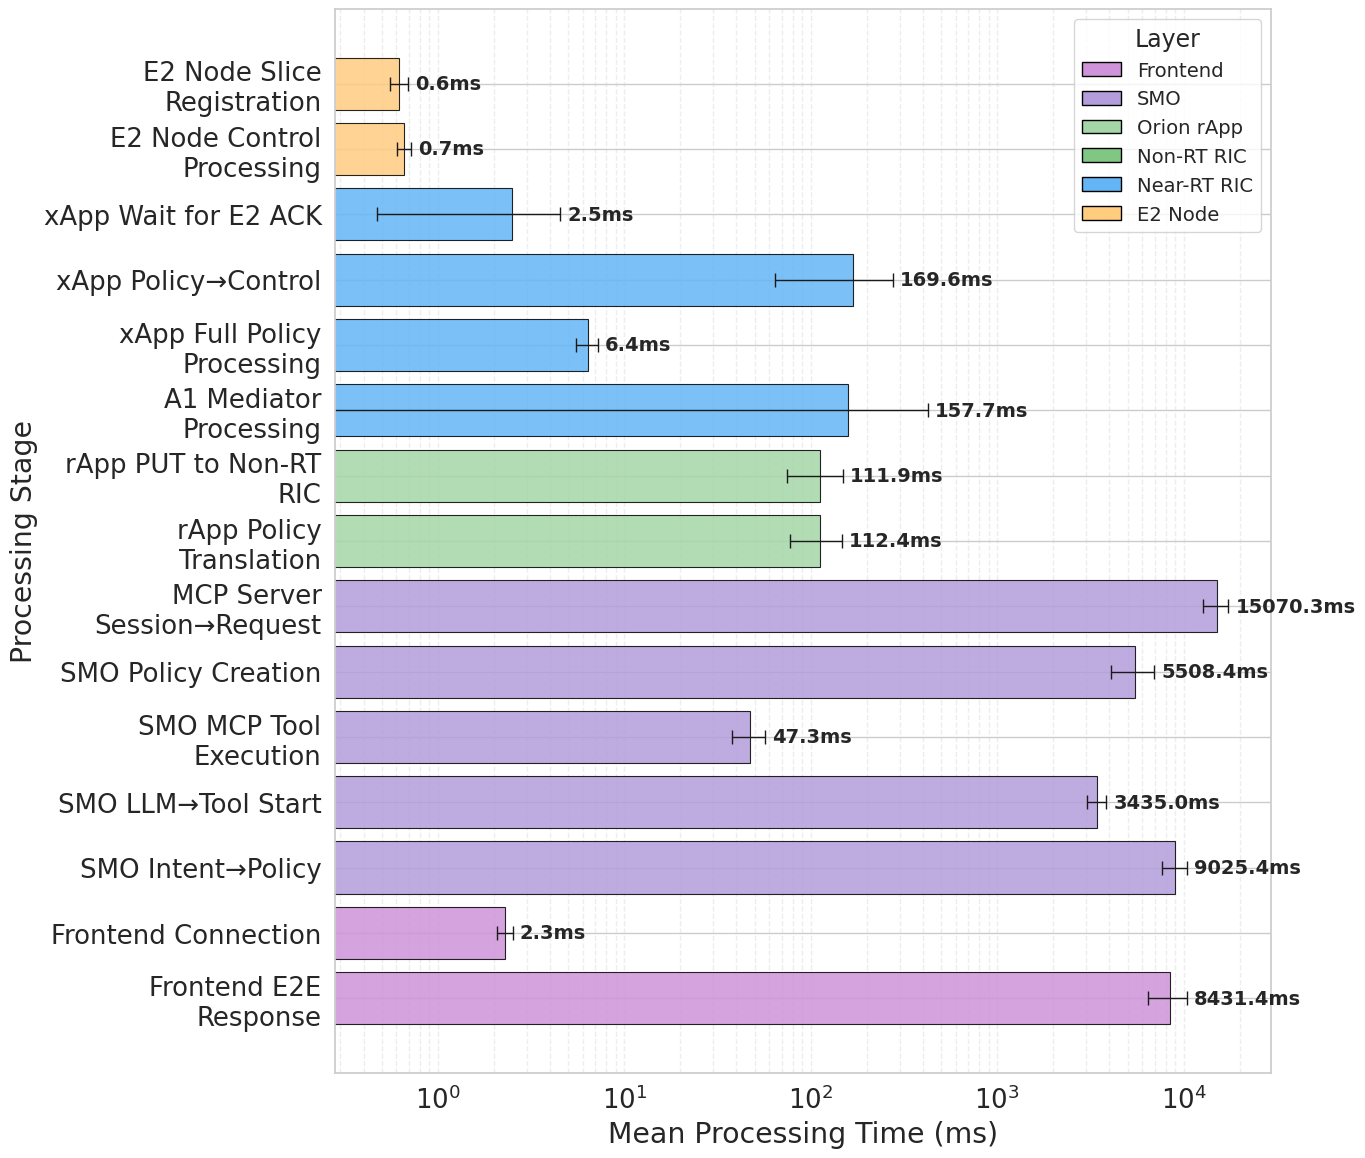


✓ Chart saved to processing_time_by_stage.png and processing_time_by_stage.pdf


In [9]:
# Bar Graph: Mean Processing Time by Stage
if len(df_processing) > 0:
    # Calculate mean and std processing time per label (stage)
    stage_stats = df_processing.groupby(["layer", "label"])["processing_time_ms"].agg(["mean", "std"]).fillna(0)
    
    # Define flow order for stages (top to bottom in chart = end to start of flow)
    # Flow: Frontend → SMO → rApp → Non-RT RIC → Near-RT RIC → E2 Node
    # NOTE: Only includes stages that have corresponding event pairs defined
    flow_order = [
        # E2 Node (end of flow - top of chart)
        "E2 Node Slice Registration",
        "E2 Node Control Processing",
        # Near-RT RIC
        "E2Term Control Round-trip",
        "xApp Wait for E2 ACK",
        "xApp Policy→Control",
        "xApp Full Policy Processing",
        "A1 Mediator Processing",
        # rApp
        "rApp PUT to Non-RT RIC",
        "rApp Policy Translation",
        # SMO
        "MCP Server Session→Request",
        "SMO Policy Creation",
        "SMO MCP Tool Execution",
        "SMO LLM→Tool Start",  # Renamed from "SMO LLM Processing"
        "SMO Intent→Policy",
        # Frontend (start of flow - bottom of chart)
        "Frontend Connection",
        "Frontend E2E Response",
    ]
    
    # Sort by flow order using a helper column
    stage_stats = stage_stats.reset_index()
    stage_stats['flow_order'] = stage_stats['label'].apply(
        lambda x: flow_order.index(x) if x in flow_order else 999
    )
    stage_stats = stage_stats.sort_values('flow_order', ascending=False)
    
    # Define colors based on architecture (matching namespace_resources.ipynb style)
    layer_colors = {
        "Frontend": "#CE93D8",   # Lighter purple for Frontend
        "SMO": "#B39DDB",        # Purple
        "rApp": "#A5D6A7",       # Green
        "Non-RT RIC": "#81C784", # Green (darker)
        "Near-RT RIC": "#64B5F6", # Blue
        "E2 Node": "#FFCC80",    # Orange
    }
    
    # Create the plot data
    import textwrap
    labels = [textwrap.fill(l, 20) for l in stage_stats["label"].values]
    means = stage_stats["mean"].values
    stds = stage_stats["std"].values
    colors = [layer_colors.get(layer, "#888888") for layer in stage_stats["layer"].values]
    
    # Create bar chart with consistent style
    fig, ax = plt.subplots(figsize=(14, max(6, len(labels) * 0.8)))
    
    bars = ax.barh(labels, means, xerr=stds, capsize=5,
                   color=colors, edgecolor='black', linewidth=0.8, alpha=0.85,
                   error_kw=dict(lw=1, capsize=5, capthick=1))
    
    # Add value labels (mean only)
    for bar, mean, std in zip(bars, means, stds):
        if mean > 0:
            width_right = mean + std if std > 0 else mean
            ax.annotate(f'{mean:.1f}ms',
                       xy=(width_right, bar.get_y() + bar.get_height() / 2),
                       xytext=(5, 0), textcoords="offset points",
                       ha='left', va='center', fontsize=14, fontweight='bold')
    
    ax.set_xlabel("Mean Processing Time (ms)")
    ax.set_ylabel("Processing Stage")
    ax.set_xscale('log')
    ax.grid(axis='x', linestyle='--', alpha=0.35, which='both')
    
    # Add legend for layers (include Frontend with distinct color)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#CE93D8', edgecolor='black', label='Frontend'),
        Patch(facecolor='#B39DDB', edgecolor='black', label='SMO'),
        Patch(facecolor='#A5D6A7', edgecolor='black', label='Orion rApp'),
        Patch(facecolor='#81C784', edgecolor='black', label='Non-RT RIC'),
        Patch(facecolor='#64B5F6', edgecolor='black', label='Near-RT RIC'),
        Patch(facecolor='#FFCC80', edgecolor='black', label='E2 Node'),
    ]
    ax.legend(handles=legend_elements, loc='upper right', title="Layer", fontsize='x-small', title_fontsize='small')
    
    plt.tight_layout()
    plt.savefig("processing_time_by_stage.png", dpi=300, bbox_inches="tight")
    plt.savefig("processing_time_by_stage.pdf", bbox_inches="tight")
    plt.show()
    print("\n✓ Chart saved to processing_time_by_stage.png and processing_time_by_stage.pdf")
else:
    print("No data available for visualization.")